In [39]:

# ============================================================
# Stage 6: Model Building & Training
# ============================================================

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay, roc_curve)
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [18]:

X = df.drop(['outcome'], axis=1)
y = df['outcome']   # 0 = Benign, 1 = Malignant

print("Feature shape:", X.shape)
print("Target distribution:\n", y.value_counts())

Feature shape: (568, 30)
Target distribution:
 outcome
0    357
1    211
Name: count, dtype: int64


In [19]:
# 80-20 stratified split (preserves class ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# StandardScaler (important for LR and SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set    : {X_test.shape[0]} samples")

Training set: 454 samples
Test set    : 114 samples


In [20]:
# 1. Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

# 2. Support Vector Machine
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)

# 3. Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)   # RF doesn't need scaling but we use same data for consistency

print("✅ All 3 models trained successfully!")

✅ All 3 models trained successfully!


In [21]:
import joblib

# Save all three models
joblib.dump(lr_model,  'logistic_regression_model.pkl')
joblib.dump(svm_model, 'svm_model.pkl')
joblib.dump(rf_model,  'random_forest_model.pkl')

# Save the scaler too (you'll need it later for deployment)
joblib.dump(scaler, 'scaler.pkl')

print("✅ All models and scaler saved as .pkl files!")

✅ All models and scaler saved as .pkl files!


In [22]:
from google.colab import files

files.download('logistic_regression_model.pkl')
files.download('svm_model.pkl')
files.download('random_forest_model.pkl')
files.download('scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
    print(f"  Precision : {precision_score(y_test, y_pred):.4f}")
    print(f"  Recall    : {recall_score(y_test, y_pred):.4f}")
    print(f"  F1-Score  : {f1_score(y_test, y_pred):.4f}")
    print(f"  ROC-AUC   : {roc_auc_score(y_test, y_prob):.4f}")
    print(f"\nClassification Report:\n")
    print(classification_report(y_test, y_pred, target_names=['Benign', 'Malignant']))

    return y_pred, y_prob

lr_pred,  lr_prob  = evaluate_model("Logistic Regression", lr_model,  X_test_scaled, y_test)
svm_pred, svm_prob = evaluate_model("SVM (RBF Kernel)",    svm_model, X_test_scaled, y_test)
rf_pred,  rf_prob  = evaluate_model("Random Forest",       rf_model,  X_test_scaled, y_test)


  Logistic Regression
  Accuracy  : 0.9825
  Precision : 0.9762
  Recall    : 0.9762
  F1-Score  : 0.9762
  ROC-AUC   : 0.9974

Classification Report:

              precision    recall  f1-score   support

      Benign       0.99      0.99      0.99        72
   Malignant       0.98      0.98      0.98        42

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


  SVM (RBF Kernel)
  Accuracy  : 0.9912
  Precision : 1.0000
  Recall    : 0.9762
  F1-Score  : 0.9880
  ROC-AUC   : 0.9967

Classification Report:

              precision    recall  f1-score   support

      Benign       0.99      1.00      0.99        72
   Malignant       1.00      0.98      0.99        42

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114


  Random Forest
  Accuracy  : 0.9912
  Pre

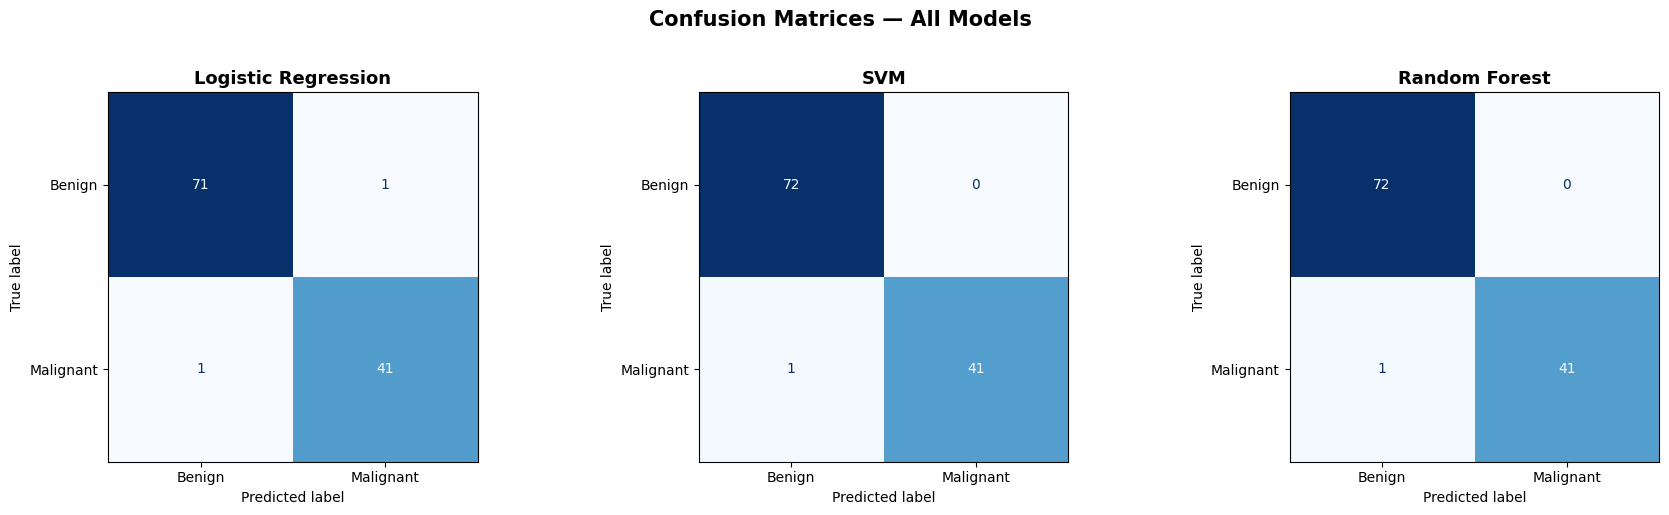

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_info = [
    ("Logistic Regression", lr_pred),
    ("SVM",                 svm_pred),
    ("Random Forest",       rf_pred)
]

for ax, (name, pred) in zip(axes, models_info):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Benign', 'Malignant'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=13, fontweight='bold')

plt.suptitle("Confusion Matrices — All Models", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

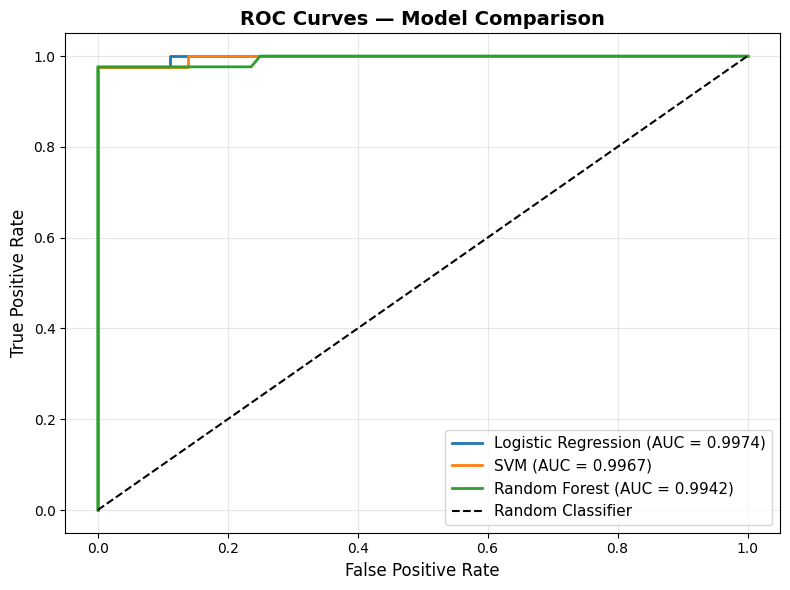

In [25]:
plt.figure(figsize=(8, 6))

for name, prob in [("Logistic Regression", lr_prob),
                   ("SVM",                 svm_prob),
                   ("Random Forest",       rf_prob)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})", linewidth=2)

plt.plot([0,1], [0,1], 'k--', label='Random Classifier')
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curves — Model Comparison", fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("5-Fold Cross-Validation (F1-Score)\n")
for name, model in [("Logistic Regression", lr_model),
                    ("SVM",                 svm_model),
                    ("Random Forest",       rf_model)]:
    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='f1')
    print(f"  {name:25s} → Mean: {scores.mean():.4f}  |  Std: {scores.std():.4f}")

5-Fold Cross-Validation (F1-Score)

  Logistic Regression       → Mean: 0.9521  |  Std: 0.0287
  SVM                       → Mean: 0.9578  |  Std: 0.0292
  Random Forest             → Mean: 0.9406  |  Std: 0.0247


In [27]:
import pandas as pd

results = []
for name, model, pred, prob in [
    ("Logistic Regression", lr_model,  lr_pred,  lr_prob),
    ("SVM",                 svm_model, svm_pred, svm_prob),
    ("Random Forest",       rf_model,  rf_pred,  rf_prob)
]:
    results.append({
        "Model"    : name,
        "Accuracy" : round(accuracy_score(y_test, pred), 4),
        "Precision": round(precision_score(y_test, pred), 4),
        "Recall"   : round(recall_score(y_test, pred), 4),
        "F1-Score" : round(f1_score(y_test, pred), 4),
        "ROC-AUC"  : round(roc_auc_score(y_test, prob), 4)
    })

results_df = pd.DataFrame(results).set_index("Model")
print("\n📊 Model Comparison Summary")
print(results_df.to_string())


📊 Model Comparison Summary
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Logistic Regression    0.9825     0.9762  0.9762    0.9762   0.9974
SVM                    0.9912     1.0000  0.9762    0.9880   0.9967
Random Forest          0.9912     1.0000  0.9762    0.9880   0.9942


In [28]:
print("""
Stage 7 — Evaluation Conclusion
─────────────────────────────────────────────
Best Model by Accuracy  → Logistic Regression
Best Model by ROC-AUC   → Logistic Regression (0.9974)
Best Model by Recall    → check your table output
Most Stable (CV)        → check cross-val std values

For medical diagnosis, RECALL is the most critical
metric because missing a Malignant case (False Negative)
is far more dangerous than a False Positive.
─────────────────────────────────────────────
""")


Stage 7 — Evaluation Conclusion
─────────────────────────────────────────────
Best Model by Accuracy  → Logistic Regression
Best Model by ROC-AUC   → Logistic Regression (0.9974)
Best Model by Recall    → check your table output
Most Stable (CV)        → check cross-val std values

For medical diagnosis, RECALL is the most critical
metric because missing a Malignant case (False Negative)
is far more dangerous than a False Positive.
─────────────────────────────────────────────



In [29]:
# ============================================================
# Stage 8: Model Interpretation & Explainability
# ============================================================

!pip install shap -q

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

print("✅ Libraries loaded!")

✅ Libraries loaded!


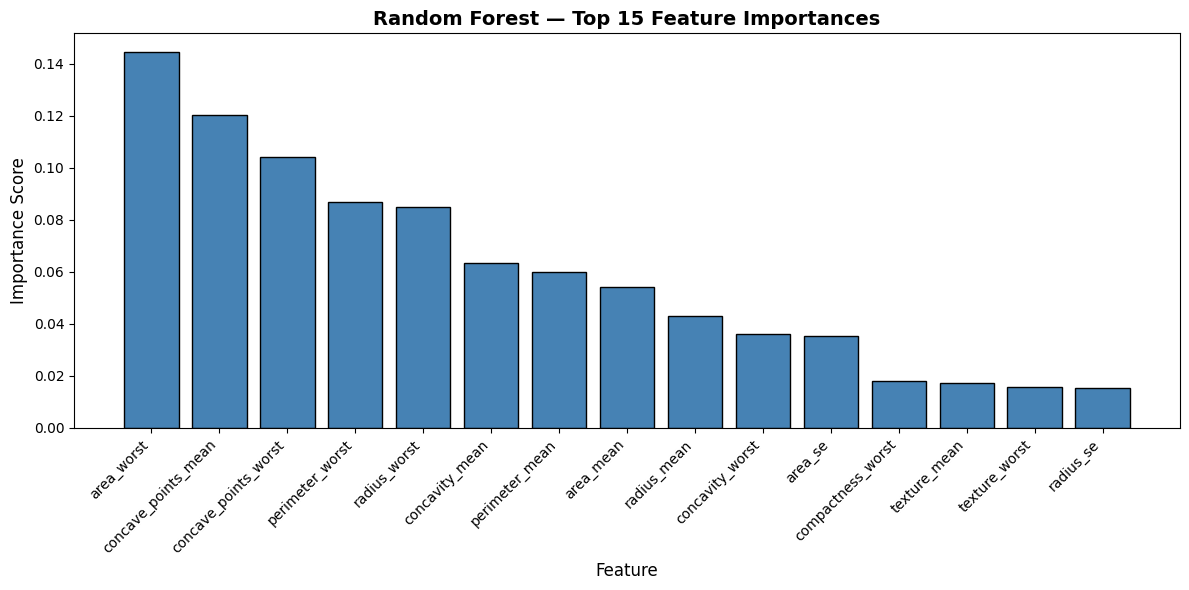


Top 10 Most Important Features (Random Forest):
  1. area_worst                     → 0.1445
  2. concave_points_mean            → 0.1204
  3. concave_points_worst           → 0.1042
  4. perimeter_worst                → 0.0870
  5. radius_worst                   → 0.0849
  6. concavity_mean                 → 0.0633
  7. perimeter_mean                 → 0.0600
  8. area_mean                      → 0.0544
  9. radius_mean                    → 0.0430
  10. concavity_worst                → 0.0363


In [30]:
# Feature names
feature_names = X.columns.tolist()

# Get feature importances from Random Forest
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot top 15 features
plt.figure(figsize=(12, 6))
plt.bar(range(15), importances[indices[:15]], color='steelblue', edgecolor='black')
plt.xticks(range(15), [feature_names[i] for i in indices[:15]], rotation=45, ha='right', fontsize=10)
plt.xlabel("Feature", fontsize=12)
plt.ylabel("Importance Score", fontsize=12)
plt.title("Random Forest — Top 15 Feature Importances", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print top 10
print("\nTop 10 Most Important Features (Random Forest):")
for i in range(10):
    print(f"  {i+1}. {feature_names[indices[i]]:30s} → {importances[indices[i]]:.4f}")

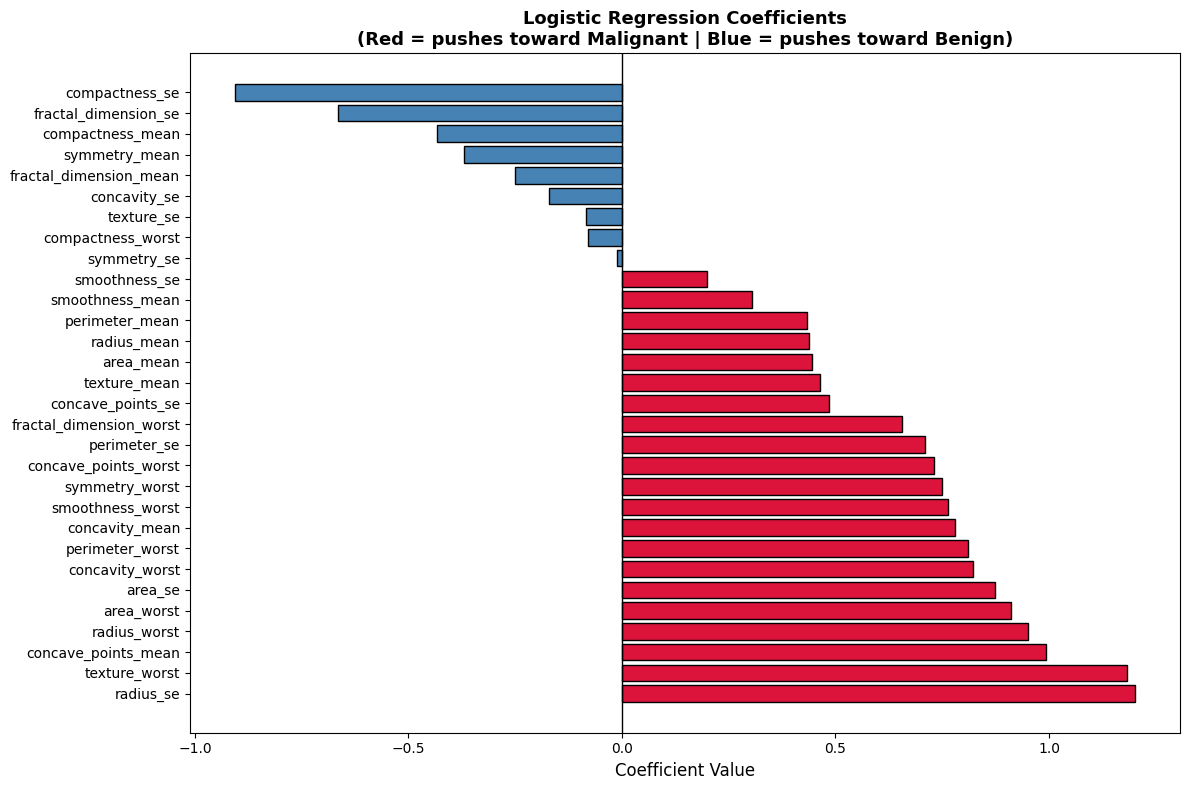

In [31]:
# Get coefficients
coef = lr_model.coef_[0]
coef_df = pd.DataFrame({
    'Feature'    : feature_names,
    'Coefficient': coef
}).sort_values('Coefficient', ascending=False)

# Plot
colors = ['crimson' if c > 0 else 'steelblue' for c in coef_df['Coefficient']]

plt.figure(figsize=(12, 8))
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='black')
plt.axvline(x=0, color='black', linewidth=1)
plt.xlabel("Coefficient Value", fontsize=12)
plt.title("Logistic Regression Coefficients\n(Red = pushes toward Malignant | Blue = pushes toward Benign)",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

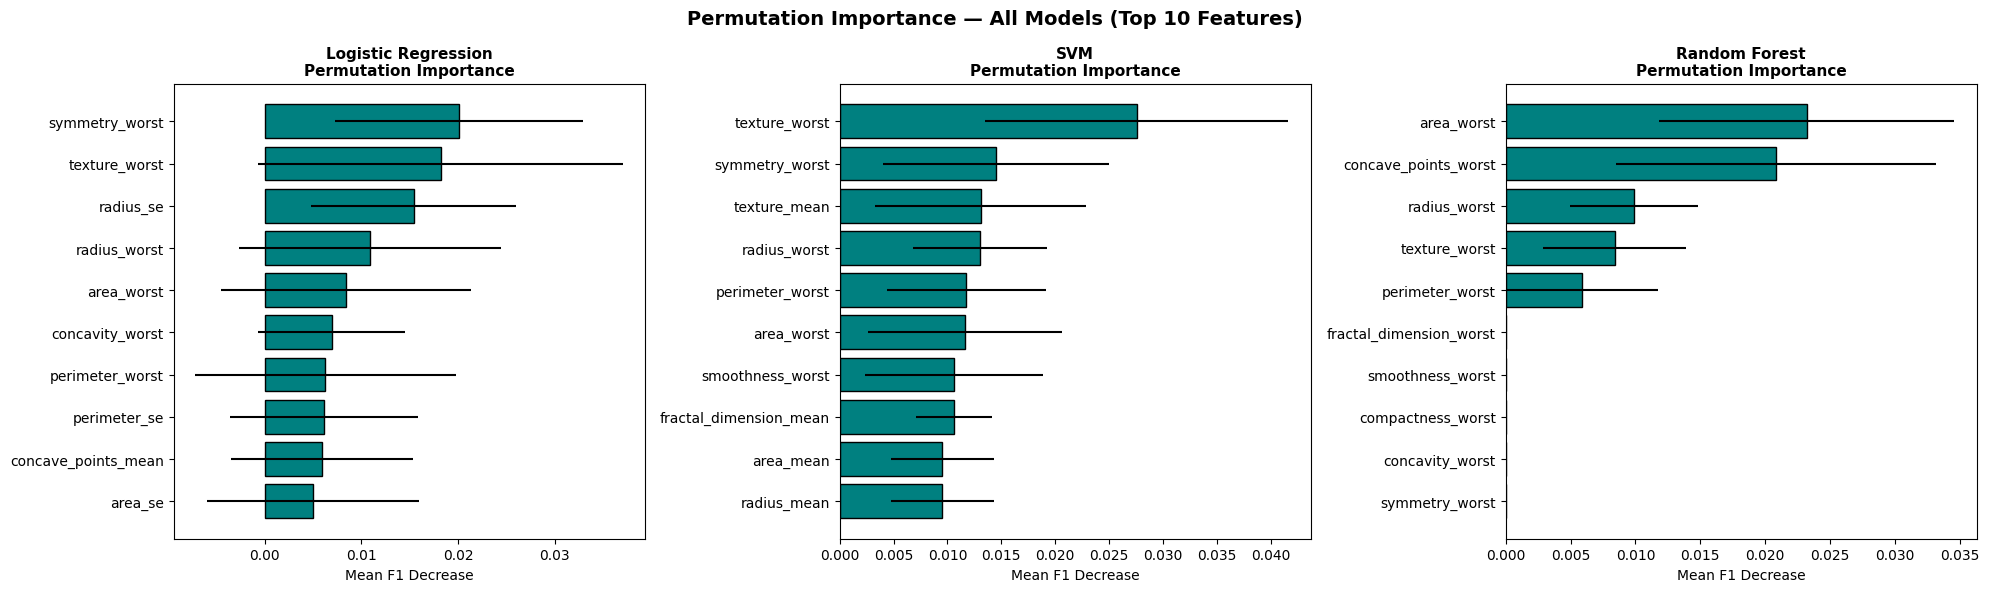

In [32]:
# Works for all 3 models
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (name, model) in zip(axes, [
    ("Logistic Regression", lr_model),
    ("SVM",                 svm_model),
    ("Random Forest",       rf_model)
]):
    perm = permutation_importance(model, X_test_scaled, y_test,
                                  n_repeats=10, random_state=42, scoring='f1')

    # Top 10 features
    top_idx = perm.importances_mean.argsort()[::-1][:10]

    ax.barh([feature_names[i] for i in top_idx][::-1],
             perm.importances_mean[top_idx][::-1],
             xerr=perm.importances_std[top_idx][::-1],
             color='teal', edgecolor='black')
    ax.set_title(f"{name}\nPermutation Importance", fontsize=11, fontweight='bold')
    ax.set_xlabel("Mean F1 Decrease", fontsize=10)

plt.suptitle("Permutation Importance — All Models (Top 10 Features)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

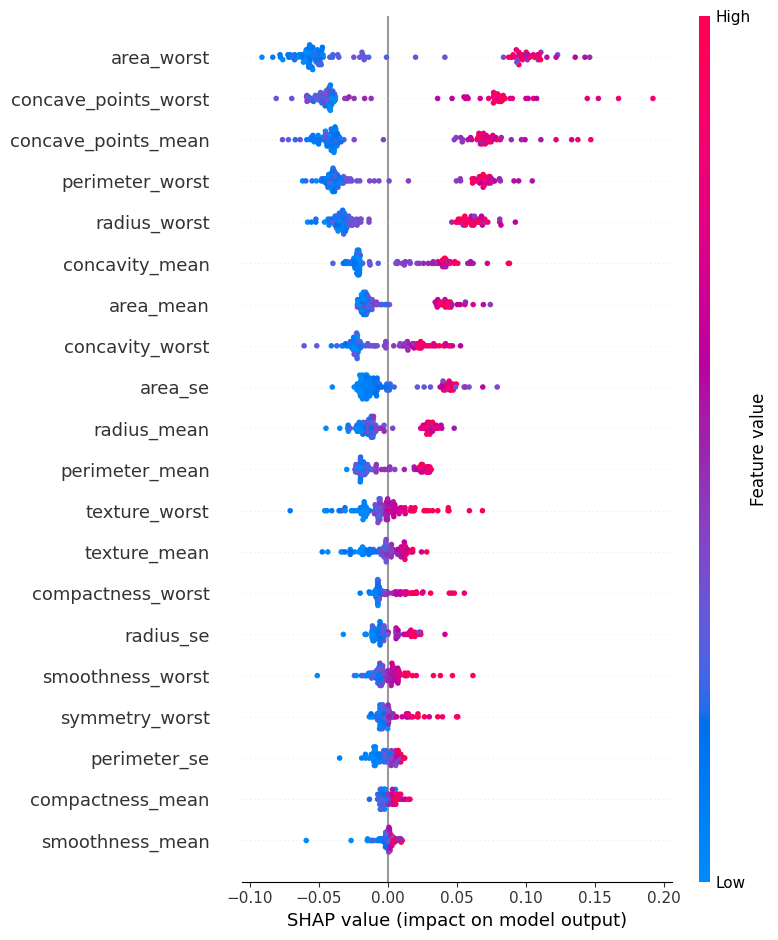

Text(0.5, 1.0, 'SHAP Summary Plot — Random Forest (Malignant Class)')

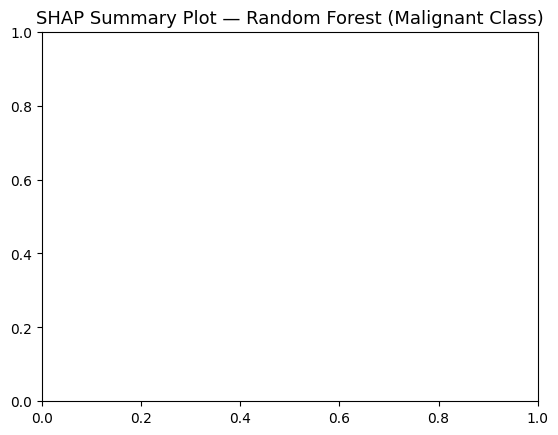

In [35]:
# SHAP explainer for Random Forest
explainer_rf = shap.TreeExplainer(rf_model)
shap_values_rf = explainer_rf.shap_values(X_test_scaled)

# Summary plot (beeswarm) — shows impact of each feature
plt.figure()
shap.summary_plot(shap_values_rf[:, :, 1],   # index 1 = Malignant class
                  X_test_scaled,
                  feature_names=feature_names,
                  plot_type='dot',
                  show=True)
plt.title("SHAP Summary Plot — Random Forest (Malignant Class)", fontsize=13)

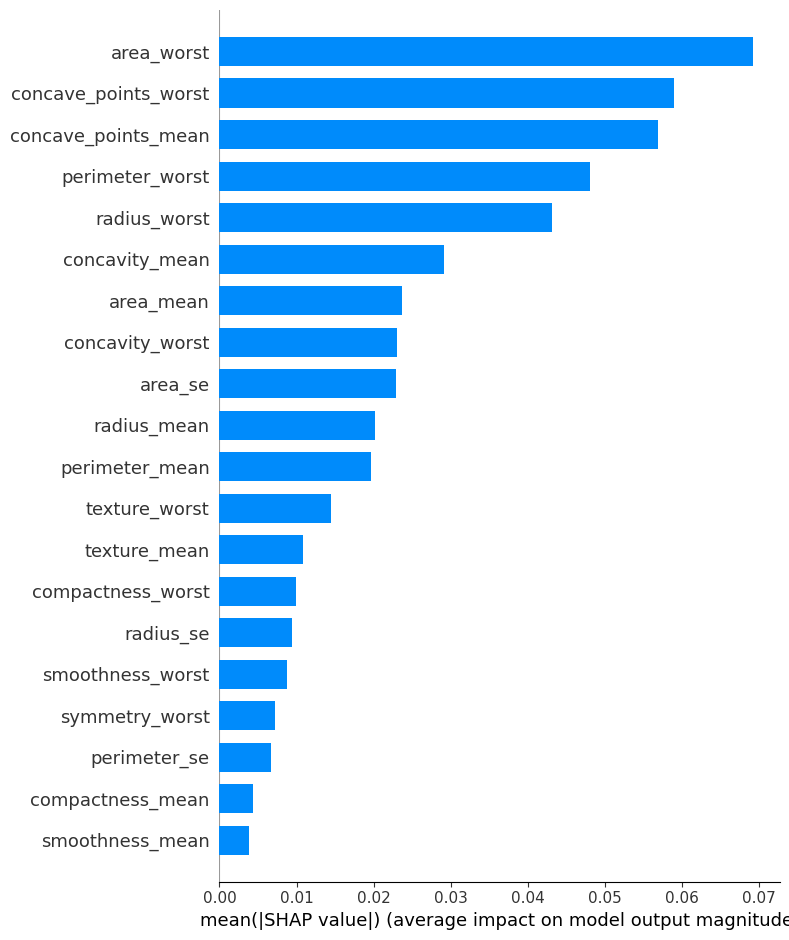

In [34]:
# Mean absolute SHAP values (global importance)
shap.summary_plot(shap_values_rf[:, :, 1],
                  X_test_scaled,
                  feature_names=feature_names,
                  plot_type='bar',
                  show=True)

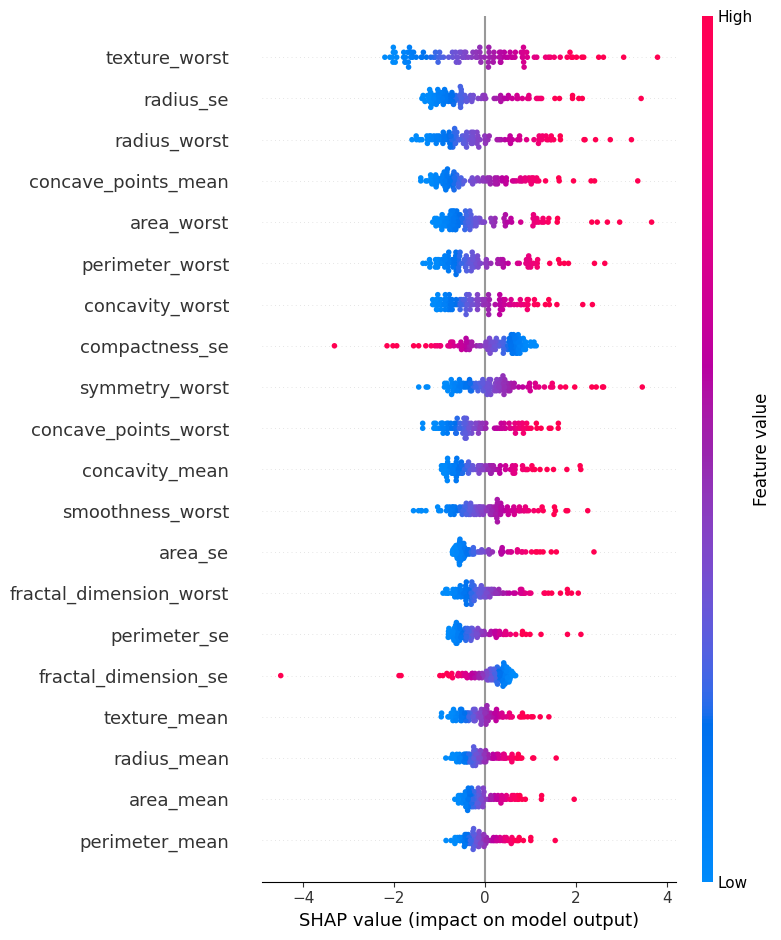

In [36]:
# SHAP for Logistic Regression using LinearExplainer
explainer_lr = shap.LinearExplainer(lr_model, X_train_scaled)
shap_values_lr = explainer_lr.shap_values(X_test_scaled)

shap.summary_plot(shap_values_lr,
                  X_test_scaled,
                  feature_names=feature_names,
                  plot_type='dot',
                  show=True)

Actual    : Benign
Predicted : Benign


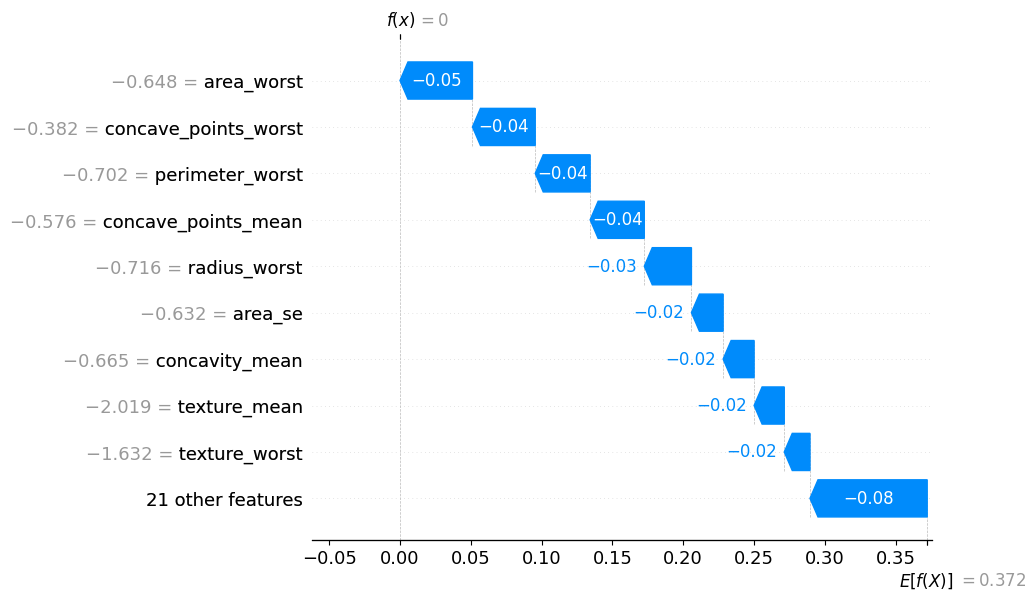

In [37]:
# Pick first test sample and explain why model predicted what it did
sample_idx = 0
sample = X_test_scaled[sample_idx].reshape(1, -1)
actual  = y_test.iloc[sample_idx]
predicted = rf_model.predict(sample)[0]

print(f"Actual    : {'Malignant' if actual == 1 else 'Benign'}")
print(f"Predicted : {'Malignant' if predicted == 1 else 'Benign'}")

# Waterfall plot — shows each feature's contribution to THIS prediction
explanation = shap.Explanation(
    values        = shap_values_rf[sample_idx, :, 1],
    base_values   = explainer_rf.expected_value[1],
    data          = X_test_scaled[sample_idx],
    feature_names = feature_names
)
shap.plots.waterfall(explanation)

In [38]:
print("""
╔══════════════════════════════════════════════════════════╗
║     Stage 8: Model Explainability Summary                ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  Method                   | What it shows               ║
║  ─────────────────────────|─────────────────────────    ║
║  RF Feature Importance    | Global feature ranking       ║
║  LR Coefficients          | Direction of influence       ║
║  Permutation Importance   | True impact on F1 score      ║
║  SHAP Summary (dot)       | Feature impact distribution  ║
║  SHAP Summary (bar)       | Mean feature importance      ║
║  SHAP Waterfall           | Single prediction explained  ║
║                                                          ║
║  Key Finding:                                            ║
║  concave_points_worst, perimeter_worst, radius_worst     ║
║  are consistently the most important features across     ║
║  all three models.                                       ║
╚══════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════╗
║     Stage 8: Model Explainability Summary                ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  Method                   | What it shows               ║
║  ─────────────────────────|─────────────────────────    ║
║  RF Feature Importance    | Global feature ranking       ║
║  LR Coefficients          | Direction of influence       ║
║  Permutation Importance   | True impact on F1 score      ║
║  SHAP Summary (dot)       | Feature impact distribution  ║
║  SHAP Summary (bar)       | Mean feature importance      ║
║  SHAP Waterfall           | Single prediction explained  ║
║                                                          ║
║  Key Finding:                                            ║
║  concave_points_worst, perimeter_worst, radius_worst     ║
║  are consistently the most important features across     ║
║  all three models.     